In [2]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
from sklearn.model_selection import train_test_split

In [4]:
np.random.seed(100)
n=100
X=np.random.normal(loc=0,scale=1,size=n)
epsilon=np.random.normal(loc=0,scale=1,size=n)

In [6]:
beta=np.array([0.2,1,1.5,4])
Y=beta[0]+beta[1]*X+beta[2]*X**2+beta[3]*X**3+epsilon

In [8]:
Xs=pd.DataFrame({'X':X,'X2':X**2,'X3':X**3,'X4':X**4,'X5':X**5,'X6':X**6,'X7':X**7,'X8':X**8
                ,'X9':X**9,'X10':X**10})
Ys=pd.DataFrame({'Y':Y})
def nCp(sigma2, estimator, Xsigma, Ysigma):
    "Negative Cp statistic"
    n, p = Xsigma.shape
    Yhat = estimator.predict(Xsigma)
    RSS = np.sum((Ysigma - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n 
design = MS(Xs).fit(Xs)
Ysigma = np.array(Ys['Y'])
Xsigma = design.transform(Xs)
model=OLS(Ysigma,Xsigma).fit()
sigma2 = model.scale
strategy=Stepwise.first_peak(design,direction='forward',max_terms=len(design.terms))
neg_Cp = partial(nCp,sigma2) 
Y_Cp= sklearn_selected(OLS,strategy,scoring=neg_Cp)
Y_Cp.fit(Xsigma, Ysigma)
Y_Cp.selected_state_

('X', 'X2', 'X3')

In [10]:
strategy_backward=Stepwise.first_peak(design,direction='backwards',max_terms=len(design.terms))
neg_Cp1 = partial(nCp,sigma2) 
Y_CpB= sklearn_selected(OLS,strategy_backward,scoring=neg_Cp1)
Y_CpB.fit(Xsigma, Ysigma)
Y_CpB.selected_state_

('X', 'X2', 'X3')

In [12]:
D = design.fit_transform(Xs)
X1 = np.asarray(D)
scaler = StandardScaler(with_mean=True,  with_std=True)
K = 5
kfold = skm.KFold(K,random_state=0,shuffle=True)
lassoCV = skl.ElasticNetCV(n_alphas=100,l1_ratio=1,cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler),('lasso', lassoCV)])
pipeCV.fit(X1, Ysigma)
tuned_lasso = pipeCV.named_steps['lasso']
print('The optimal value of lambda is:',tuned_lasso.alpha_)

The optimal value of lambda is: 0.011422938509194142


In [14]:
lambdas, soln_array = skl.Lasso.path(Xsigma,Ysigma,l1_ratio=1,n_alphas=100,max_iter=10000)[:2]
soln_path = pd.DataFrame(soln_array.T,columns=D.columns,index=-np.log(lambdas))

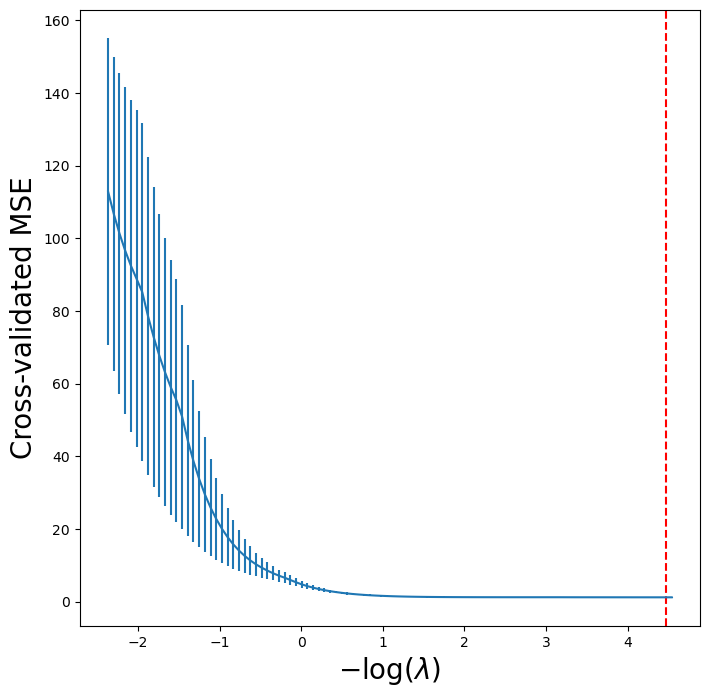

In [18]:
lassoCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_lasso.alpha_), c='r', ls='--')
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

In [20]:
tuned_lasso.coef_

array([ 0.00000000e+00,  7.23101437e-01,  1.56911795e+00,  1.06337083e+01,
        2.77621504e-01,  0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
        0.00000000e+00, -4.86290744e-03,  0.00000000e+00])

In [22]:
X.shape

(100,)

In [24]:
beta=[6,10]
Ynew=beta[0]+beta[1]*X**7+epsilon

In [26]:
Ysnew=pd.DataFrame({'Y':Ynew})
design = MS(Xs).fit(Xs)
Ysigman = np.array(Ysnew['Y'])
model=OLS(Ysigman,Xsigma).fit()
sigma2n = model.scale
strategy=Stepwise.first_peak(design,direction='forward',max_terms=len(design.terms))
neg_Cpn = partial(nCp,sigma2n) 
Y_Cpn= sklearn_selected(OLS,strategy,scoring=neg_Cpn)
Y_Cpn.fit(Xsigma, Ysigman)
Y_Cpn.selected_state_

('X7',)

In [28]:
scaler = StandardScaler(with_mean=True,  with_std=True)
K = 5
kfold = skm.KFold(K,random_state=0,shuffle=True)
lassoCVn = skl.ElasticNetCV(n_alphas=100,l1_ratio=1,cv=kfold)
pipeCVn = Pipeline(steps=[('scaler', scaler),('lasso', lassoCV)])
pipeCVn.fit(X1, Ysigman)
tuned_lasson = pipeCVn.named_steps['lasso']

print('The optimal value of lambda is:',tuned_lasso.alpha_)

The optimal value of lambda is: 0.6268263569044815


In [30]:
tuned_lasson.coef_

array([  0.        ,  -2.74928715,   0.53179374,   0.        ,
         0.        ,  76.93506706,   0.        , 435.77147222,
         0.        , 118.82385473,  -0.        ])

In [32]:
college=load_data('College')

In [34]:
college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      777 non-null    category
 1   Apps         777 non-null    int64   
 2   Accept       777 non-null    int64   
 3   Enroll       777 non-null    int64   
 4   Top10perc    777 non-null    int64   
 5   Top25perc    777 non-null    int64   
 6   F.Undergrad  777 non-null    int64   
 7   P.Undergrad  777 non-null    int64   
 8   Outstate     777 non-null    int64   
 9   Room.Board   777 non-null    int64   
 10  Books        777 non-null    int64   
 11  Personal     777 non-null    int64   
 12  PhD          777 non-null    int64   
 13  Terminal     777 non-null    int64   
 14  S.F.Ratio    777 non-null    float64 
 15  perc.alumni  777 non-null    int64   
 16  Expend       777 non-null    int64   
 17  Grad.Rate    777 non-null    int64   
dtypes: category(1), float64(1), in

In [36]:
college

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [38]:
college.Private.astype('category')

0      Yes
1      Yes
2      Yes
3      Yes
4      Yes
      ... 
772     No
773    Yes
774    Yes
775    Yes
776    Yes
Name: Private, Length: 777, dtype: category
Categories (2, object): ['No', 'Yes']

In [40]:
college_train,college_test = train_test_split(college,test_size=0.5,random_state=0)
college_train['Private01']=np.where(college_train['Private']=='Yes',1,0)
college_test['Private01']=np.where(college_test['Private']=='Yes',1,0)

In [42]:
design = MS(college.columns.drop(['Apps','Private'])).fit(college)
X_train = design.transform(college_train)
y_train=college_train['Apps']
result=OLS(y_train,X_train).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Apps   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     292.4
Date:                Mon, 12 May 2025   Prob (F-statistic):          4.67e-199
Time:                        22:18:27   Log-Likelihood:                -3251.6
No. Observations:                 388   AIC:                             6537.
Df Residuals:                     371   BIC:                             6604.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept   -1112.5384    552.802     -2.013      0.045   -2199.557     -25.520
Accept          1.2854      0.068     18.832      0.000       1.151       1.420
Enroll         -0.2739      0.253     -1.081      0.280      -0.772       0.224
Top10perc      57.7756      8.176      7.067      0.000      41.699      73.852
Top25perc     -21.9565      6.595     -3.329      0.001     -34.925      -8.988
F.Undergrad     0.0934      0.043      2.195      0.029       0.010       0.177
P.Undergrad     0.0408      0.040      1.017      0.310      -0.038       0.120
Outstate       -0.0657      0.027     -2.474      0.014      -0.118      -0.013
Room.Board      0.1635      0.072      2.274      0.024       0.022       0.305
Books          -0.0654      0.320     -0.204      0.838      -0.695       0.564
Personal       -0.0505      0.088     -0.572      0.568      -0.224       0.123
PhD            -8.3451      7.720     -1.081      0.280     -23.526       6.835
Terminal        0.6134      8.510      0.072      0.943     -16.120      17.347
S.F.Ratio      25.8068     17.667      1.461      0.145      -8.933      60.547
perc.alumni    -9.7264      6.317     -1.540      0.124     -22.148       2.695
Expend          0.0809      0.020      4.079      0.000       0.042       0.120
Grad.Rate      10.9956      4.346      2.530      0.012       2.449      19.542
==============================================================================
Omnibus:                      217.309   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2145.651
Skew:                           2.186   Prob(JB):                         0.00
Kurtosis:                      13.659   Cond. No.                     1.69e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.69e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [44]:
design_test=MS(college.columns.drop(['Private','Apps'])).fit(college)
X_test=design_test.transform(college_test)
Y_hat=result.predict(X_test)
MSE_ols=np.mean((Y_hat-college_test['Apps'])**2)
print('The obtained test error for the least squares linear model is ',MSE_ols)

The obtained test error for the least squares linear model is  1244800.2699891704


In [46]:
K = 10
kfold = skm.KFold(K,random_state=0,shuffle=True)
lambdas = 10**np.linspace(8, -2, 100) / college['Apps'].std()
param_grid = {'ridge__alpha': lambdas}
#ridge = skl.ElasticNet(alpha=lambdas[9], l1_ratio=0)
ridge = skl.ElasticNet(alpha=lambdas[9], l1_ratio=0.0001, max_iter=10000, tol=1e-3)
scaler = StandardScaler(with_mean=True,  with_std=True)
pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)])
grid = skm.GridSearchCV(pipe,param_grid,cv=kfold,scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)
grid.best_params_['ridge__alpha']

0.007024410108016933

In [48]:
opt_lambda=grid.best_params_['ridge__alpha']

In [52]:
ridge_opt = skl.ElasticNet(alpha=opt_lambda, l1_ratio=0.0001, max_iter=10000, tol=1e-3)
pipe_ridge = Pipeline(steps=[('scaler', scaler), ('ridge', ridge_opt)])
result_ridge=pipe_ridge.fit(X_train, y_train)

In [54]:
Y_hat_ridge=result_ridge.predict(X_test)
MSE_ridge=np.mean((Y_hat_ridge-college_test['Apps'])**2)
print('The obtained test error for the ridge regression model is ',MSE_ridge)

The obtained test error for the ridge regression model is  1335127.4742451499


In [56]:
param_grid_2 = {'lasso__alpha': lambdas}
lasso= skl.ElasticNet(alpha=lambdas[9], l1_ratio=1)
pipe_2 = Pipeline(steps=[('scaler', scaler), ('lasso', lasso)])
grid_2 = skm.GridSearchCV(pipe_2,param_grid_2,cv=kfold,scoring='neg_mean_squared_error')
grid_2.fit(X_train, y_train)
opt_lambda_lasso=grid_2.best_params_['lasso__alpha']
print('The optimal lmabda chosen for lasso regression is',opt_lambda_lasso )

The optimal lmabda chosen for lasso regression is 9.504362464388217


In [58]:
lasso_opt = skl.ElasticNet(alpha=opt_lambda_lasso, l1_ratio=1)
pipe_lasso = Pipeline(steps=[('scaler', scaler), ('lasso', lasso_opt)])
result_lasso=pipe_lasso.fit(X_train, y_train)

In [60]:
Y_hat_lasso=result_lasso.predict(X_test)
MSE_lasso=np.mean((Y_hat_lasso-college_test['Apps'])**2)
print('The obtained test error for the lasso regression model is ',MSE_lasso)

The obtained test error for the lasso regression model is  1274819.3068367443


In [62]:
tuned_lasso = pipe_lasso.named_steps['lasso']

In [64]:
tuned_lasso.coef_

array([   0.        , 3116.63401003,   -0.        ,  936.41417856,
       -334.5727745 ,  335.31207055,   58.97120064, -213.10391846,
        161.37116451,   -0.        ,  -23.51599141, -105.54207564,
         -0.        ,   87.14757609, -122.71487843,  378.45990596,
        158.32546935])

In [126]:
pca = PCA(n_components=2)
linreg = skl.LinearRegression()
param_grid = {'pca__n_components': range(1, min(X_train.shape) + 1)}  
pipe_pca=Pipeline(steps=[('scaler', scaler), ('pca', pca),('linreg', linreg)])
grid = skm.GridSearchCV(pipe_pca,param_grid,cv=kfold,scoring='neg_mean_squared_error')
pipe_pca.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('linreg', LinearRegression())])

In [128]:
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=2)),
                                       ('linreg', LinearRegression())]),
             param_grid={'pca__n_components': range(1, 18)},
             scoring='neg_mean_squared_error')

In [136]:
n_comp = param_grid['pca__n_components']
df=pd.DataFrame({'num_components':n_comp,'CV_MSE':-grid.cv_results_['mean_test_score']})
M = df.loc[df['CV_MSE'].idxmin(), 'num_components']
M #M=df['CV_MSE'].argmin(skipna=True)+1

16

In [138]:
df['CV_MSE']

0     1.263998e+07
1     3.455587e+06
2     3.328103e+06
3     3.155404e+06
4     2.752468e+06
5     1.842890e+06
6     1.749478e+06
7     1.731994e+06
8     1.704531e+06
9     1.735617e+06
10    1.709167e+06
11    1.737374e+06
12    1.796620e+06
13    1.782246e+06
14    1.385877e+06
15    1.354219e+06
16    1.354219e+06
Name: CV_MSE, dtype: float64

In [140]:
df['CV_MSE'].argmin(skipna=True)

15

In [142]:
pca_M = PCA(n_components=M)
linreg = skl.LinearRegression()
param_grid_M = {'pca_M__n_components': range(1, 19)}
pipe_pca_M=Pipeline(steps=[('scaler', scaler), ('pca', pca_M),('linreg', linreg)])
result_pca=pipe_pca_M.fit(X_train, y_train)

In [144]:
Yhat_pca=result_pca.predict(X_test)
MSE_pca=np.mean((Yhat_pca-college_test['Apps'])**2)
print('The obtained test error for the pca model is',MSE_pca)

The obtained test error for the pca model is 1244800.2699891443


In [146]:
pls = PLSRegression(n_components=2,scale=True)
pls.fit(X_train,y_train)

PLSRegression()

In [148]:
param_grid = {'n_components': range(1, min(X_train.shape) + 1)}
grid = skm.GridSearchCV(pls,param_grid,cv=kfold,scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=PLSRegression(),
             param_grid={'n_components': range(1, 18)},
             scoring='neg_mean_squared_error')

In [149]:
n_comp = param_grid['n_components']
df=pd.DataFrame({'num_components':n_comp,'CV_MSE':-grid.cv_results_['mean_test_score']})
M=df['CV_MSE'].argmin(skipna=True)+1
M

11

In [150]:
pls = PLSRegression(n_components=M,scale=True)
result_pls=pls.fit(X_train,y_train)
Yhat_pls=result_pls.predict(X_test)
Y_test=np.asarray(college_test['Apps']).reshape(-1,1)
MSE_pls=np.mean((Yhat_pls-Y_test)**2)
print('The obtained test error for the pca model is',MSE_pls)

The obtained test error for the pca model is 26585187.85862519


In [120]:
results_df=pd.DataFrame({'Models':['OLS','Ridge','Lasso','PCR','PLS'],'Test_MSE':
                       [MSE_ols,MSE_ridge,MSE_lasso,MSE_pca,MSE_pls]})
results_df

,Models,Test_MSE
0,OLS,1.244800e+06
1,Ridge,1.335127e+06
2,Lasso,1.274819e+06
3,PCR,1.244800e+06
4,PLS,2.658519e+07


In [122]:
college['Apps'].mean()

3001.6383526383524

In [124]:
RMSE=np.sqrt(results_df['Test_MSE'])
RMSE

0    1115.706175
1    1155.477163
2    1129.078964
3    1115.706175
4    5156.082608
Name: Test_MSE, dtype: float64